<h1> Nerual Computing Project </h1>

You are asked to evaluate critically, compare and contrast two NECO methods applied to your choice of data set using Python and Jupyter notebook.

Dataset: UCI ML Repository Dry Bean -  https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

This is a Classification Task. 
* 16 Features
* 7 Labels.

The two Nerual Computing methods I will compare are classification using a Multi Layer Perceptron (MLP) vs a Support Vector Machine (SVM).

In [1]:
# Import Libraries
# Permitted - NumPy, PyTorch, Scikit Learn, Skorch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

import time

# 'Save' Models
import joblib


In [2]:
# Make device agnostic code
device = "cpu" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [59]:
LOAD_MODEL = True

In [4]:
# Enable GPU use on Apple Silicon
print(torch.backends.mps.is_available())


True


<h2> Extract Load Transform Data </h2>

<h4>Load Data</h4>

In [5]:
# Import Data from UCI ML REPO
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 

# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 
  
# metadata 
#print(dry_bean.metadata) 
  
# variable information 
print(dry_bean.variables)

               name     role         type demographic  \
0              Area  Feature      Integer        None   
1         Perimeter  Feature   Continuous        None   
2   MajorAxisLength  Feature   Continuous        None   
3   MinorAxisLength  Feature   Continuous        None   
4       AspectRatio  Feature   Continuous        None   
5      Eccentricity  Feature   Continuous        None   
6        ConvexArea  Feature      Integer        None   
7     EquivDiameter  Feature   Continuous        None   
8            Extent  Feature   Continuous        None   
9          Solidity  Feature   Continuous        None   
10        Roundness  Feature   Continuous        None   
11      Compactness  Feature   Continuous        None   
12     ShapeFactor1  Feature   Continuous        None   
13     ShapeFactor2  Feature   Continuous        None   
14     ShapeFactor3  Feature   Continuous        None   
15     ShapeFactor4  Feature   Continuous        None   
16            Class   Target  C

In [6]:
# Inspect Data Shape
print(X.columns)
print(X.shape)

print(y.columns)
print(y.shape)


Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='object')
(13611, 16)
Index(['Class'], dtype='object')
(13611, 1)


In [7]:
# Check for Missing Data
print('Missing Feature Values: ', X.isna().sum())
print('Missing Target Values: ',y.isna().sum())

Missing Feature Values:  Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64
Missing Target Values:  Class    0
dtype: int64


In [8]:
# Inspect Feature Data
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [9]:
# Feature Data Summary Stats
X.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [10]:
# Target Data Summary Stats
(y.describe())

,Class
count,13611
unique,7
top,DERMASON
freq,3546


In [11]:
# Features Summary Statistics 
X.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [12]:
# Distribution of Target Variable
(y.value_counts(normalize=True))

Class   
DERMASON    0.260525
SIRA        0.193667
SEKER       0.148924
HOROZ       0.141650
CALI        0.119756
BARBUNYA    0.097127
BOMBAY      0.038351
Name: proportion, dtype: float64

<h4> Transform Data </h4>

1. Split → X_train, X_test, y_train, y_test
2. Scale X (fit on X_train, transform all)
3. Split X_train_scaled → X_train_scaled, X_val_scaled (and y_train → y_train, y_val)
4. Encode y (fit on y_train, transform all three)
5. Convert to tensors
6. Wrap in DataLoaders

In [13]:
# Train/Test Split - Stratified Sampling 80 Train 20 Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2, random_state=42, stratify=y
    )
print(y_train.value_counts(normalize=True))

Class   
DERMASON    0.260562
SIRA        0.193699
SEKER       0.148880
HOROZ       0.141624
CALI        0.119765
BARBUNYA    0.097079
BOMBAY      0.038391
Name: proportion, dtype: float64


In [14]:
# Feature Scaling - Z Transform (Normalize) all feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=43, stratify=y_train
)

In [16]:
# Encoding Categorical Variables with IntegerLabel

# Label Encoding (only encode train set)
le = LabelEncoder()

# Fit the encoder on the train data
y_train = le.fit_transform(y_train)

# Apply fitted encoder on the validation and train data
y_val = le.transform(y_val)
y_test = le.transform(y_test)

/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.d

In [17]:
# Convert Data to Tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print('X Train: ', X_train.shape)
print('Y Train: ', y_train.shape)

print('X Validation: ', X_val.shape)
print('Y Validation: ', y_val.shape)

print('X Test: ', X_test.shape)
print('Y Test: ', y_test.shape)

X Train:  torch.Size([8710, 16])
Y Train:  torch.Size([8710])
X Validation:  torch.Size([2178, 16])
Y Validation:  torch.Size([2178])
X Test:  torch.Size([2723, 16])
Y Test:  torch.Size([2723])


In [18]:
# Wrap in Data Loader
batch_size=32

# Training Dataloader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

# Validation DataLoader
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size, shuffle=True)

# Test DataLoader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset)

<h2> Multi-Layer Perceptron (MLP) Implementation </h2>

<h4> MLP Structure and Hyperparameter Selection </h4>

* <b> Input Layer </b> : 16 Features
* <b> Output Later </b>: 7 possible Classes
* <b> Hidden Layers </b>: 1-2
* <b> Hidden Neurons </b>: 64, 128 (Based on Group Work)
* <b> Activation Function </b>: ReLU (Hidden Layers), Softmax (Output)
* <b> Loss </b>: Cross Entropy Loss

<h4> Structure of Implementation </h4>

* Stage 1: Single layer [128], SGD, no momentum, no weight decay → baseline
* Stage 2: Add momentum=0.9 → does it help?
* Stage 3: Try [128,64] and [128,128] architectures
* Stage 4: Add weight decay → does regularisation help?
* Stage 5: Best MLP config → compare against SVM


Grid Search with Cross Validation (i.e 5 Fold)


<h4>Baseline Model </h4>

* The baseline model uses the assumptions developed based on intial investication (group coursework)
* 1 Hidden Layer, Hidden Layer Dimension = 128, Learning Rate = 0.1. No Momentum, No Weight Decay. 300 Epochs.

In [19]:
# Build the Model
class Classifier(nn.Module):
    def __init__(self,input_dim,hidden_dim,output_dim): # Structure of the NN
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self,x): # Forward Pass
        x = self.hidden(x)
        x = self.act(x)
        x = self.output(x)
        return x

In [20]:
#Function for model instantiation
def build_model_and_optimizer(input_dim,hidden_dim,output_dim,lr,momentum,weight_decay):  
    
    # Instantiation of model
    model = Classifier(input_dim,hidden_dim,output_dim).to(device) 

    # Loss Function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.SGD(
        model.parameters(),
        lr = lr,
        momentum = momentum,
        weight_decay = weight_decay
    )
    return model, criterion, optimizer

Baseline Model

 Test Loss: 0.2221 | Accuracy: 0.9196

               precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.96      0.94       326
    DERMASON       0.88      0.95      0.92       709
       HOROZ       0.95      0.94      0.95       386
       SEKER       0.93      0.97      0.95       406
        SIRA       0.91      0.79      0.84       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723


 Accuracy:  0.919573999265516

 Weighted F1: 0.9184961559562552

 [[241   0  16   1   0   2   5]
 [  0 104   0   0   0   0   0]
 [  6   0 313   0   4   2   1]
 [  0   0   0 676   1   9  23]
 [  2   0   8   6 364   0   6]
 [  3   0   0   6   0 392   5]
 [  5   0   0  78  13  17 414]]


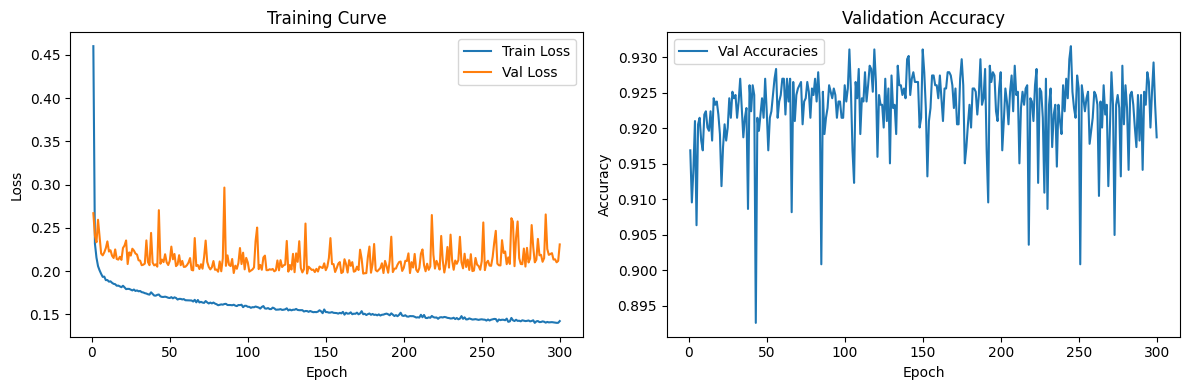

In [66]:
# Baseline Model

# Parameters
input_dim = 16
hidden_dim = 128
output_dim = 7
lr = 0.1
momentum = 0.0
weight_decay = 0.0

# Initialize Model & Opitimizer
model, criterion, optimizer = build_model_and_optimizer(input_dim,hidden_dim,output_dim,lr,momentum,weight_decay)

if LOAD_MODEL and os.path.exists('mlp_baseline.pth'):
    model.load_state_dict(torch.load('mlp_baseline.pth'))
else:
    start = time.time()

    # Training Loop
    num_epochs = 300

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss=0
        for X_batch, y_batch in train_loader:
            # Forward Pass
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            # Calculate Loss
            loss = criterion(outputs, y_batch)
            # Backwards pass (compute gradients)
            optimizer.zero_grad()
            loss.backward()
            # Update parameters (Model Weights)
            optimizer.step()
            train_loss += loss.item() #train loss accumulates per batch
        
        avg_train_loss = train_loss/len(train_loader) #average train loss per batch for epoch

        # Model Evaluation
        model.eval() #switch model to eval
        correct, total, val_loss = 0,0,0
        with torch.no_grad(): # disables gradient computation
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item() # CEL calculates average loss per batch, .item converts to py float
                predicted = torch.argmax(outputs, dim=1) # argmax returns index of highest value, for each row dim=1 find argmax col
                correct += (predicted == y_batch).sum().item() 
                total += y_batch.size(0)

        avg_val_loss = val_loss/len(val_loader)

        if ((epoch+1)%25 ==0):
            #print(f"Epoch {epoch+1}/{num_epochs}, Loss={loss.item():.4f}")
            print(f"Epoch {epoch+1} | Average Train Loss per Batch = {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {correct/total:.4f}")

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(correct/total)

    baseline_train_time = time.time() - start
    print(f"\nBaseline MLP training time: {baseline_train_time:.2f}s")
    torch.save(model.state_dict(), 'mlp_baseline.pth')

# Test Model Evaluation
model.eval()
correct, total, test_loss = 0,0,0
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        test_loss += criterion(outputs, y_batch).item()
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        all_preds.extend(predicted.numpy())
        all_targets.extend(y_batch.numpy())

avg_test_loss = test_loss/len(test_loader)
accuracy = correct/total

print('Baseline Model')

print('\n',f'Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}')

print('\n',classification_report(all_targets, all_preds, target_names=le.classes_))

# Accuracy
print('\n',"Accuracy: ", accuracy_score(all_targets, all_preds))

#Weighted F1
print('\n','Weighted F1:', f1_score(all_targets, all_preds, average='weighted'))

# Confusion Matrix
print('\n', confusion_matrix(all_targets, all_preds))

#Plots
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 4))

#Loss Curve
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()

#Accuracy Curve
plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, label='Val Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

<h4> Randomized Hyperparameter Search </h4>

After the baseline models results - A wider search of potential hyperparameters needed to be conducted. A randomized hyperparameter search would assess the better hyperparameter selection and additionally a broader idea about choice of number of hidden layers.

In the baseline model a 80/20 Holdout Validation split was used for the Training Data. When conducting the random search 5-fold cross validation was employed in order to improve robusness - In order to do this the original Holdout validation splits was recombined with the Training split.

As RandomizedSearchCV is part of the sklearn package - Skorch must be used to translate the Pytorch model implementation for use with this function.

In [22]:
# Random Search
from skorch import NeuralNetClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [23]:
# Recombine initial holdout validation (80/20) split so training data is together - Cross Validation can now be used here

X_search = np.concatenate([X_train, X_val])
y_search = np.concatenate([y_train, y_val])

print(X_search.shape)
print(y_search.shape)

(10888, 16)
(10888,)


<h4> Random Search 1 Hidden Layer MLP</h4>

In [25]:
# Random Hyperparameter Search for Single Hidden Layer

# This differs from the baseline implementation by introducing momentum, weight decay and varying batch sizes.

# Using Skorch to wrap Pytorch Model so its compatible with RandomziedSearchCV

# Define Parameter Grid
param_dist = {
    'module__hidden_dim' : [64,128,256],
    'lr': [0.01, 0.05, 0.1],
    'optimizer__momentum': [0.0, 0.9],
    'optimizer__weight_decay': [0.0, 0.001, 0.01],
    'max_epochs': [100, 300, 500],
    'batch_size': [32, 64, 128]
    }

# Skorch wrap Pytorch Model - NeuralNetClassifier is Skorch wrapper Class.
# Manual Training Loop and DataLoader Creation handled by Skorch.

net = NeuralNetClassifier(
    module = Classifier,    # Feed Skorch the Pytorch Model - Skorch instantiates model    
    module__input_dim = 16, # module__ skorch passing arguments into models __init__
    module__hidden_dim = 128, # this argument will be overrriden by search    
    module__output_dim = 7,      
    
    # Skorch builds the model automatically (no manual function)
    optimizer = torch.optim.SGD, 
    criterion = nn.CrossEntropyLoss, # Loss
    verbose = 0 # Prints traning process
)


if LOAD_MODEL and os.path.exists('mlp_1layer_final.pth'):
    random_search = joblib.load('mlp_1layer_search.pkl')
else: 
    start = time.time()
    random_search = RandomizedSearchCV(
        estimator=net,
        param_distributions=param_dist,
        n_iter = 20,
        cv = 5,
        scoring = 'f1_weighted',
        n_jobs = 1,     # keep at 1 for PyTorch
        random_state = 42
    )
    random_search.fit(X_search, y_search)
    mlp_1layer_train_time = time.time() - start
    print(f"\n1-Layer MLP search training time: {mlp_1layer_train_time:.2f}s")
    joblib.dump(random_search, 'mlp_1layer_search.pkl')



#Best average F1 across 5 fold Cross Validation - Hyperparam Selection Metric
print(random_search.best_params_)
print(random_search.best_score_)


1-Layer MLP search training time: 3583.98s
{'optimizer__weight_decay': 0.0, 'optimizer__momentum': 0.0, 'module__hidden_dim': 128, 'max_epochs': 500, 'lr': 0.05, 'batch_size': 128}
0.9348562752460499


In [60]:
# Evaluate Single Hidden Layer Random Hyperparameter Search

# Best model
best_model = random_search.best_estimator_

# Predict on Test-set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print('Single Hidden Layer - Best Model Evaluation')

# Accuracy
print('\n',"Accuracy: ", accuracy_score(y_test, y_pred))

#Weighted F1
print('\n','Weighted F1:', f1_score(y_test, y_pred, average='weighted'))

# Full breakdown per Class
print('\n',classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
print('\n',confusion_matrix(y_test, y_pred))



Single Hidden Layer - Best Model Evaluation

 Accuracy:  0.9243481454278369

 Weighted F1: 0.9242952775176317

               precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723


 [[241   0  16   0   0   3   5]
 [  0 104   0   0   0   0   0]
 [ 10   0 307   0   6   2   1]
 [  0   0   0 655   0  11  43]
 [  1   0   4   6 369   0   6]
 [  3   0   0   6   0 386  11]
 [  3   0   0  53   9   7 455]]


<h4> Random Search 2 Hidden Layer MLP </h4>

* These results show that the baseline model can be improved upon. There is still however some class seperation issues. 
<br> <br> 
* Previous literature uses a 2 layer architecture - Architechture in documentation is tapered 2 layers 17-12-3-7
* [REF] https://www.sciencedirect.com/science/article/pii/S0168169919311573?via=ihub

In [27]:
# Rebuild the model to allow for varying hidden layers
# This model is entirely tuneable tuple inputs of hidden layers
# (64, 64) (64, 32) (128, 64) (32, 64)

class TuneableClassifier(nn.Module):
    def __init__(self,input_dim,hidden_dims,output_dim): # Structure of the NN
        super().__init__()
        layers = [] # List for Layers
        in_dim = input_dim # starts as the input dim
        for h in hidden_dims:   # loop for input + hidden layers
            layers.append(nn.Linear(in_dim,h))
            #layers.append(nn.ReLU) - Relu was cousing problems in skorch - moved to the forward pass 
            in_dim=h
        layers.append(nn.Linear(in_dim, output_dim)) #Final Layer
        self.network = nn.ModuleList(layers) #* here unpacks list - nn.Sequential takes individual layers a seperate args
    
    def forward(self,x): # Forward Pass
        for layer in self.network[:-1]:  # all layers except last
            x = F.relu(layer(x))
        return self.network[-1](x)       # final layer, no activation

In [28]:
# Instantiate the model using Skorch

# Define parameter grid 
 
param_dist = {
    'module__hidden_dims': [(64, 64),(64, 32),(128, 64),(32, 64)],
    'lr': [0.01, 0.05, 0.1],
    'optimizer__momentum': [0.0, 0.9],
    'optimizer__weight_decay': [0.0, 0.001, 0.01],
    'max_epochs': [100, 300, 500],
    'batch_size': [32, 64, 128]
}

# Skorch wrap Pytorch Model 
net = NeuralNetClassifier(
    module = TuneableClassifier,    # Feed Skorch the Pytorch Model - Skorch instantiates model    
    module__input_dim = 16, # module__ skorch passing arguments into models __init__
    module__hidden_dims = (128,), # this argument will be overrriden by search    
    module__output_dim = 7,      
    
    # Skorch builds the model automatically (no manual function)
    optimizer = torch.optim.SGD, 
    criterion = nn.CrossEntropyLoss, # Loss
    verbose = 0 # Prints traning process
)

if LOAD_MODEL and os.path.exists('mlp_2layer_search.pkl'):
    random_search = joblib.load('mlp_2layer_search.pkl')
else:
    start=time.time()
    # Random Search Params
    random_search = RandomizedSearchCV(
        estimator=net,
        param_distributions=param_dist,
        n_iter = 20,
        cv = 5,
        scoring = 'f1_weighted',
        n_jobs = 1,     # keep at 1 for PyTorch
        random_state = 42
    )
    random_search.fit(X_search, y_search)
    mlp_2layer_train_time = time.time() - start
    print(f"\n2-Layer MLP search training time: {mlp_2layer_train_time:.2f}s")
    joblib.dump(random_search, 'mlp_2layer_search.pkl')



#Best average F1 across 5 fold Cross Validation - Hyperparam Selection Metric
print(random_search.best_params_)
print(random_search.best_score_)



2-Layer MLP search training time: 1975.51s
{'optimizer__weight_decay': 0.001, 'optimizer__momentum': 0.0, 'module__hidden_dims': (128, 64), 'max_epochs': 500, 'lr': 0.01, 'batch_size': 64}
0.93408550601596


In [63]:
# Evaluate 2 Hidden Layer Random Hyperparameter Search

# Best model
best_model2 = random_search.best_estimator_

# Predict on Test-set
y_pred2 = best_model2.predict(X_test) # This returns hard class labels
y_prob2 = best_model2.predict_proba(X_test) # This returns probabilities

# Accuracy
print('\n',"Accuracy: ", accuracy_score(y_test, y_pred2))

#Weighted F1
print('\n','Weighted F1:', f1_score(y_test, y_pred2, average='weighted'))

# Full breakdown per Class
print('\n',classification_report(y_test, y_pred2, target_names=le.classes_))

# Confusion Matrix
print('\n',confusion_matrix(y_test, y_pred2))


 Accuracy:  0.9243481454278369

 Weighted F1: 0.9242952775176317

               precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723


 [[241   0  16   0   0   3   5]
 [  0 104   0   0   0   0   0]
 [ 10   0 307   0   6   2   1]
 [  0   0   0 655   0  11  43]
 [  1   0   4   6 369   0   6]
 [  3   0   0   6   0 386  11]
 [  3   0   0  53   9   7 455]]


Saving Models

Joblib-pickle 

In [30]:
# Save MLP (both versions)
torch.save(best_model.module_.state_dict(), 'mlp_1layer_final.pth')
torch.save(best_model2.module_.state_dict(), 'mlp_2layer_final.pth')

<h4>Best MLP Model Evaluation</h4>

In [31]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

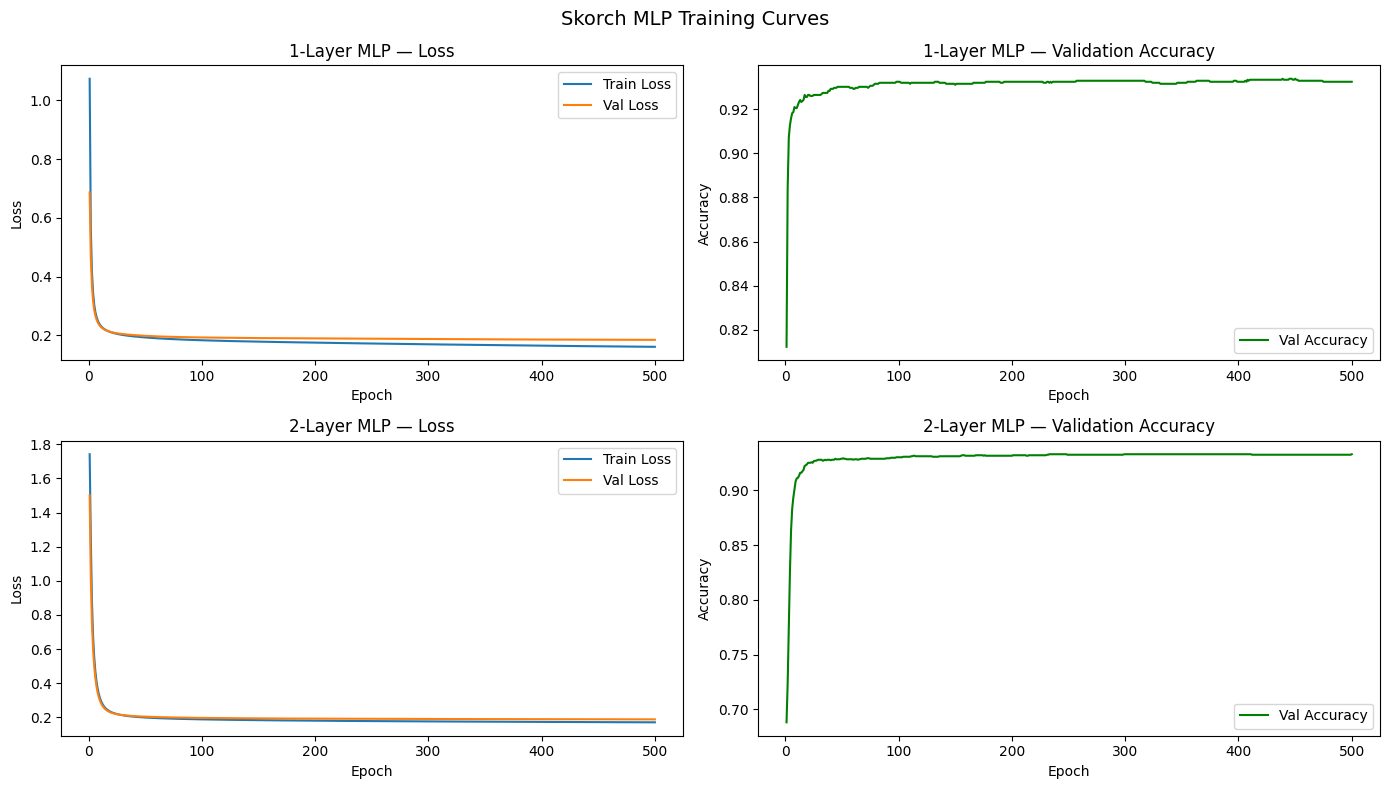

In [46]:
# Training Curves - 1-Layer vs 2-Layer MLP (Skorch history)

def plot_training_curves(model, title, ax_loss, ax_acc):
    history = model.history
    epochs = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss = [h['valid_loss'] for h in history]
    val_acc = [h['valid_acc'] for h in history]

    ax_loss.plot(epochs, train_loss, label='Train Loss')
    ax_loss.plot(epochs, val_loss, label='Val Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'{title} — Loss')
    ax_loss.legend()

    ax_acc.plot(epochs, val_acc, label='Val Accuracy', color='green')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_title(f'{title} — Validation Accuracy')
    ax_acc.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_training_curves(best_model,  '1-Layer MLP', axes[0, 0], axes[0, 1])
plot_training_curves(best_model2, '2-Layer MLP', axes[1, 0], axes[1, 1])

plt.suptitle('Skorch MLP Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

1-Layer MLP — Macro average AUC: 0.9957
2-Layer MLP — Macro average AUC: 0.9955


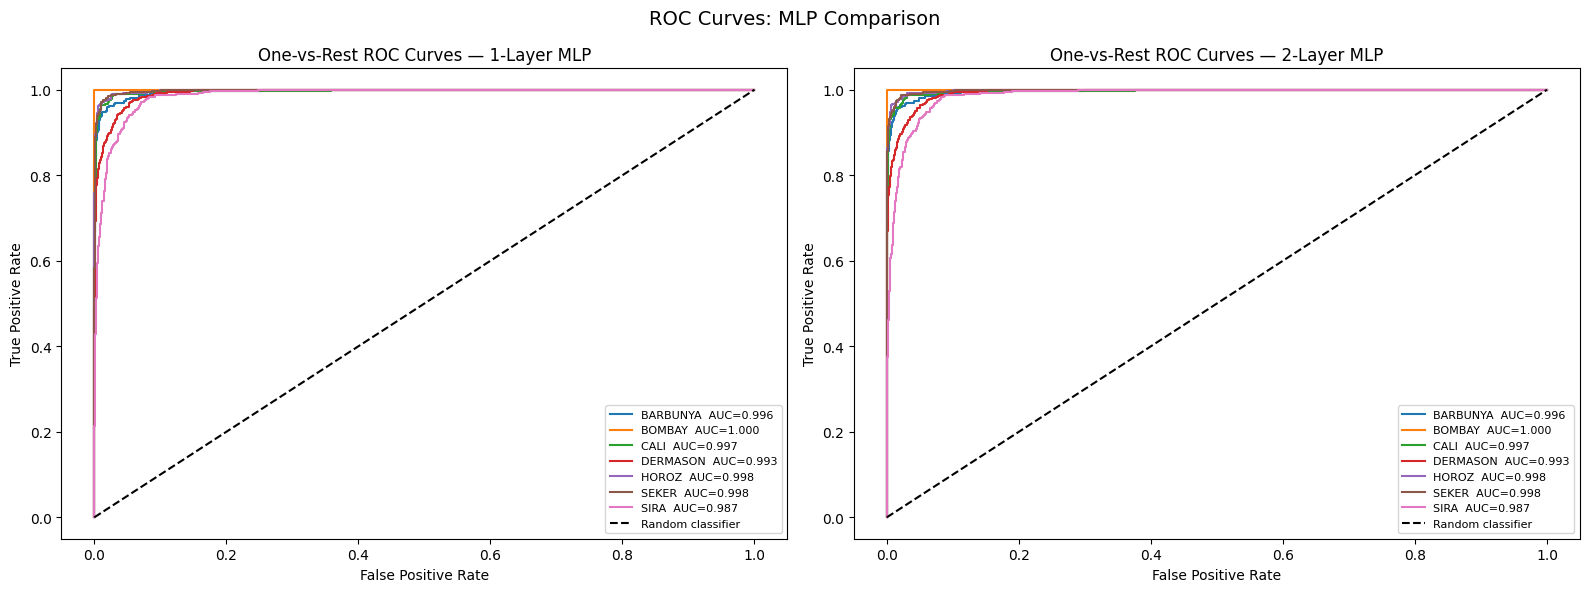

In [47]:
# Model Evaluation
# ROC Curves — 1-Layer vs 2-Layer MLP

y_test_np = y_test.numpy()
y_test_bin = label_binarize(y_test_np, classes=[0,1,2,3,4,5,6])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_prob, title in zip(axes, [y_prob, y_prob2], ['1-Layer MLP', '2-Layer MLP']):
    auc_scores = []
    for i in range(7):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, label=f'{le.classes_[i]}  AUC={roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'One-vs-Rest ROC Curves — {title}')
    ax.legend(loc='lower right', fontsize=8)
    print(f'{title} — Macro average AUC: {sum(auc_scores)/len(auc_scores):.4f}')

plt.suptitle('ROC Curves: MLP Comparison', fontsize=14)
plt.tight_layout()
plt.show()

<h2> Support Vector Machine (SVM) Implementation </h2>

In [50]:
from sklearn.svm import SVC
import os

In [55]:
# Hyperparameters
param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4]  # only used when kernel='poly'
}

# Model
svm = SVC(random_state=42, probability=True)

if LOAD_MODEL and os.path.exists('svm_search.pkl'):
    random_search = joblib.load('svm_search.pkl')
else:
    start=time.time()
    # Random Search
    random_search = RandomizedSearchCV(
        estimator=svm,
        param_distributions=param_dist,
        n_iter=50,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_search, y_search)
    svm_train_time = time.time()-start
    print(f"\nSVM search training time: {svm_train_time}s")
    joblib.dump(random_search, 'svm_search.pkl')
print(random_search.best_params_)
print(random_search.best_score_)


SVM search training time: 177.9560079574585s
{'kernel': 'rbf', 'gamma': 'auto', 'degree': 2, 'C': 10}
0.9327390261747937


In [65]:
# Evaluate SVM Random Hyperparameter Search

# Best model
best_model3 = random_search.best_estimator_

# Predict on Test-set
y_pred3 = best_model3.predict(X_test)

# Accuracy
print('\n',"Accuracy: ", accuracy_score(y_test, y_pred3))

# Full breakdown per Class
print('\n',classification_report(y_test, y_pred3, target_names=le.classes_))

# Confusion Matrix
print('\n',confusion_matrix(y_test, y_pred3))


 Accuracy:  0.9243481454278369

               precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723


 [[241   0  16   0   0   3   5]
 [  0 104   0   0   0   0   0]
 [ 10   0 307   0   6   2   1]
 [  0   0   0 655   0  11  43]
 [  1   0   4   6 369   0   6]
 [  3   0   0   6   0 386  11]
 [  3   0   0  53   9   7 455]]


In [ ]:
#ROC Curve

<h4> SVM evaluation </h4>

<h4> Comparison of best models </h4>

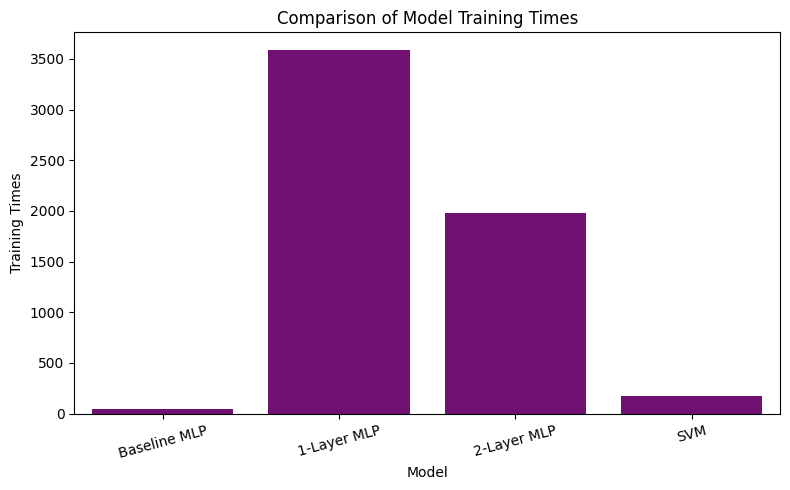

In [57]:
# Training time / Testing Time

training_times_df = pd.DataFrame(
    {
        'Model': ['Baseline MLP','1-Layer MLP','2-Layer MLP','SVM'],
        'Training Times': [baseline_train_time, mlp_1layer_train_time, mlp_2layer_train_time, svm_train_time]
    }
)

plt.figure(figsize=(8,5))
sns.barplot(data = training_times_df, x='Model', y='Training Times',color='purple')
plt.title('Comparison of Model Training Times')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

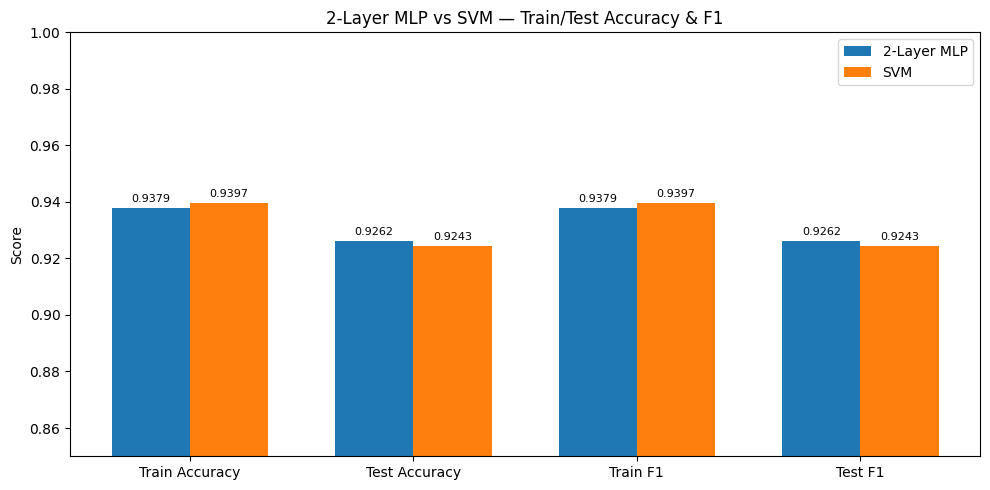

In [58]:
# Accuracy - F1 Score  Bar Chart
from sklearn.metrics import accuracy_score, f1_score

# Training predictions
y_train_pred2 = best_model2.predict(X_search)
y_train_pred3 = best_model3.predict(X_search)

# Scores
results = {
    '2-Layer MLP': {
        'Train Accuracy': accuracy_score(y_search, y_train_pred2),
        'Test Accuracy':  accuracy_score(y_test, y_pred2),
        'Train F1':       f1_score(y_search, y_train_pred2, average='weighted'),
        'Test F1':        f1_score(y_test, y_pred2, average='weighted'),
    },
    'SVM': {
        'Train Accuracy': accuracy_score(y_search, y_train_pred3),
        'Test Accuracy':  accuracy_score(y_test, y_pred3),
        'Train F1':       f1_score(y_search, y_train_pred3, average='weighted'),
        'Test F1':        f1_score(y_test, y_pred3, average='weighted'),
    }
}

# Plot
metrics = ['Train Accuracy', 'Test Accuracy', 'Train F1', 'Test F1']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [results['2-Layer MLP'][m] for m in metrics], width, label='2-Layer MLP')
bars2 = ax.bar(x + width/2, [results['SVM'][m] for m in metrics], width, label='SVM')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('2-Layer MLP vs SVM — Train/Test Accuracy & F1')
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Confusion matrix comparison - Heatmap?

print('\n2 Layer MLP:\n')




print('\nSVM:\n')


2 Layer MLP:


SVM:



In [ ]:
# ROC AUC

In [ ]:
# MLP LOSS CURVE